<a href="https://colab.research.google.com/github/olkanth/MSCS_634_Lab_4/blob/main/MSCS_634_Lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Laxmi Kanth Oruganti
### MSCS-634 : Advanced Big Data and Data Mining
### Lab 4: Regression Analysis with Regularization Techniques

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Step 1: Data Preparation

### Feature Descriptions

| Feature | Description |
|---------|-------------|
| `age`   | Age (years) |
| `sex`   | Sex (binary encoded) |
| `bmi`   | Body Mass Index |
| `bp`    | Average Blood Pressure |
| `s1`    | Total serum cholesterol (TC) |
| `s2`    | Low-density lipoproteins (LDL) |
| `s3`    | High-density lipoproteins (HDL) |
| `s4`    | Total cholesterol / HDL ratio |
| `s5`    | Log of serum triglycerides (LTG) |
| `s6`    | Blood sugar level (GLU) |


In [2]:
# Load the Diabetes dataset from sklearn.datasets.
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
# Print the shape of the data and target.
print(diabetes.data.shape)
print(diabetes.target.shape)
# diabetes.target
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target
df.head(10)

(442, 10)
(442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346,97.0
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0


In [3]:
# Explore the dataset’s features, target values, and data distribution
df.describe()

# Perform any necessary data cleaning steps (e.g., handling missing values).
df.isnull().sum()
# df.isna().sum()


,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


## Step 2: Linear Regression

In [4]:
# Implement a Simple Linear Regression model using one feature as the independent variable and the target variable as the dependent variable
# Split the data into training and testing sets.

# Visualize the model's predictions against the actual data.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['bmi']]
y = df[['target']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

model.coef_, model.intercept_



(array([[998.57768914]]), array([152.00335421]))

In [5]:
# Train the model and evaluate its performance using MAE, MSE, RMSE, and R²
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict using the trained model
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)


MAE: 52.259976445345536
MSE: 4061.8259284949268
RMSE: 63.73245584860925
R²: 0.23335039815872138


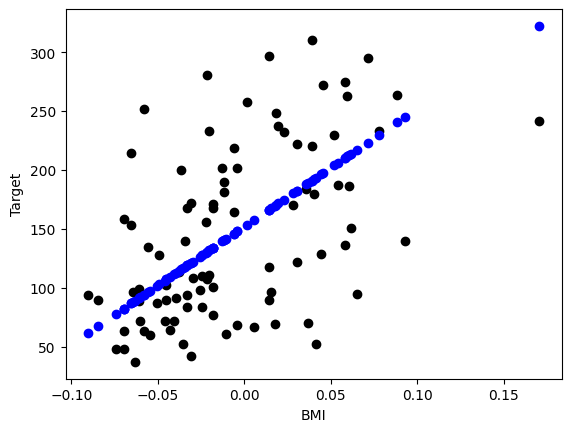

In [6]:
# Visualize the model's predictions against the actual data
plt.scatter(X_test, y_test, color='black')
plt.scatter(X_test, y_pred, color='blue')
plt.xlabel('BMI')
plt.ylabel('Target')
plt.show()


## Step 3: Multiple Regression

In [7]:
# Implement a Multiple Regression model using multiple independent variables to predict the target variable.
df.corr()['target']


,target
age,0.187889
sex,0.043062
bmi,0.586450
bp,0.441482
s1,0.212022
s2,0.174054
s3,-0.394789
s4,0.430453
s5,0.565883
s6,0.382483


### Dropping all the colums but bmi, bp	, s4, s5 as they are closely corrlated to target

In [8]:
# Dropping all the colums but bmi, bp , s4, s5 as they are closely corrlated to target
X_multiple = df[['bmi', 'bp', 's4', 's5']]
y_multiple = df[['target']]

X_multiple.shape, y_multiple.shape

((442, 4), (442, 1))

In [9]:

X_multiple_train, X_multiple_test, y_multiple_train, y_multiple_test = train_test_split(
    X_multiple, y_multiple, test_size=0.2, random_state=42
)

print(f"Training samples : {X_multiple_train.shape[0]}")
print(f"Testing  samples : {X_multiple_test.shape[0]}")
print(f"Train/Test split : 80% / 20%")

Training samples : 353
Testing  samples : 89
Train/Test split : 80% / 20%


In [10]:
model_multi = LinearRegression() # Create a new model instance for multiple regression
model_multi.fit(X_multiple_train, y_multiple_train)

model_multi.coef_, model_multi.intercept_

(array([[631.96026639, 290.3417701 ,  90.46395121, 442.7254354 ]]),
 array([151.72480629]))

In [11]:
# Display all feature coefficients
coef_df = pd.DataFrame({
    "Feature"    : X_multiple.columns.values,
    "Coefficient": model_multi.coef_.flatten() # Use the new model_multi
}).sort_values("Coefficient", key=abs, ascending=False).reset_index(drop=True)

print("Feature Coefficients (sorted by absolute value):")
print(coef_df)

Feature Coefficients (sorted by absolute value):
  Feature  Coefficient
0     bmi   631.960266
1      s5   442.725435
2      bp   290.341770
3      s4    90.463951


In [12]:
# Generate predictions on the test set
y_multiple_pred = model_multi.predict(X_multiple_test)

# Calculate metrics
mae  = mean_absolute_error(y_multiple_test, y_multiple_pred)
mse  = mean_squared_error(y_multiple_test, y_multiple_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_multiple_test, y_multiple_pred)

print("=" * 40)
print("MODEL PERFORMANCE METRICS")
print("=" * 40)
print(f"MAE  (Mean Absolute Error)       : {mae:.4f}")
print(f"MSE  (Mean Squared Error)        : {mse:.4f}")
print(f"RMSE (Root Mean Squared Error)   : {rmse:.4f}")
print(f"R²   (Coefficient of Det.)       : {r2:.4f}")
print("=" * 40)


MODEL PERFORMANCE METRICS
MAE  (Mean Absolute Error)       : 44.3127
MSE  (Mean Squared Error)        : 2900.2926
RMSE (Root Mean Squared Error)   : 53.8544
R²   (Coefficient of Det.)       : 0.4526


Text(0.5, 1.0, 'Actual vs. Predicted Values')

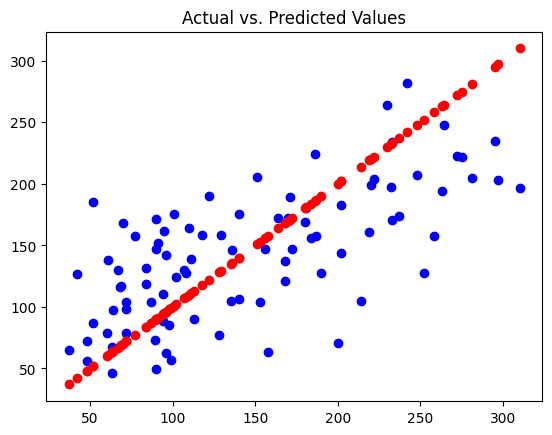

In [13]:
# Visualize the predicted values versus the actual values.
import matplotlib.pyplot as plt

plt.scatter(y_multiple_test, y_multiple_pred, color='blue')
plt.scatter(y_multiple_test, y_multiple_test, color='red')
# plt.xlabel("Actual Values")
# plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")



In [14]:
residuals = y_multiple_test - y_multiple_pred # Ensure consistency with multiple regression variables
comparison_df = pd.DataFrame({
    "Actual"   : y_multiple_test.values[:20].flatten(),
    "Predicted": y_multiple_pred[:20].flatten().round(2),
    "Residual" : residuals.values[:20].flatten().round(2),
    "Abs Error": np.abs(residuals.values[:20].flatten()).round(2)
})

comparison_df

,Actual,Predicted,Residual,Abs Error
0,219.0,160.62,58.38,58.38
1,70.0,167.86,-97.86,97.86
2,202.0,182.69,19.31,19.31
3,230.0,264.06,-34.06,34.06
4,111.0,139.13,-28.13,28.13
5,84.0,118.87,-34.87,34.87
6,242.0,281.86,-39.86,39.86
7,272.0,222.80,49.20,49.20
8,94.0,88.45,5.55,5.55
9,96.0,141.93,-45.93,45.93


## Step 4: Polynomial Regression

Polynomial Regression extends linear regression by generating **higher-order feature combinations**.  
For degree `d` with `n` features, `PolynomialFeatures` creates all combinations up to degree `d`:

> degree 2: x₁, x₂, x₁², x₁·x₂, x₂², ...

A **Pipeline** is used to chain `PolynomialFeatures → StandardScaler → LinearRegression`  
so that feature scaling is applied correctly after polynomial expansion.


Mean Squared Error (MSE): 4061.83
Coefficient of Determination (R^2): 0.23


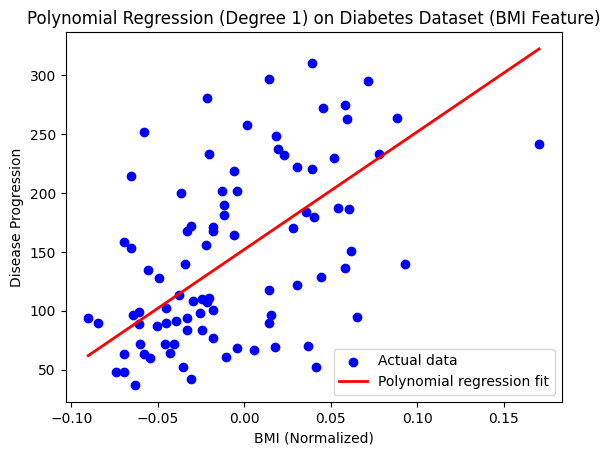

Mean Squared Error (MSE): 4085.03
Coefficient of Determination (R^2): 0.23


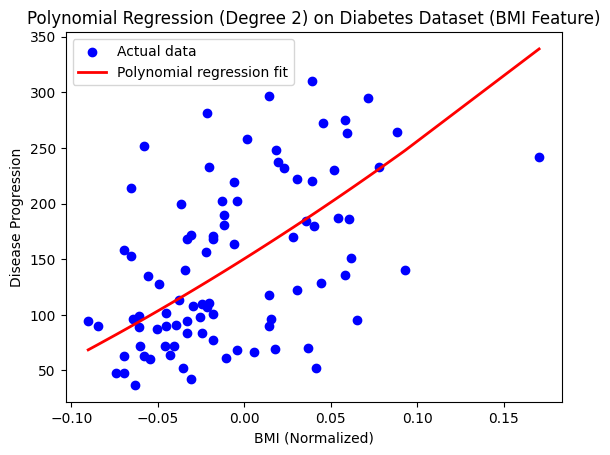

Mean Squared Error (MSE): 4064.44
Coefficient of Determination (R^2): 0.23


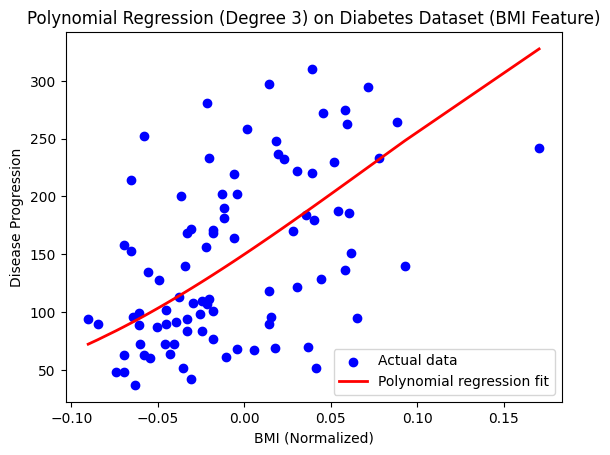

Mean Squared Error (MSE): 4226.14
Coefficient of Determination (R^2): 0.20


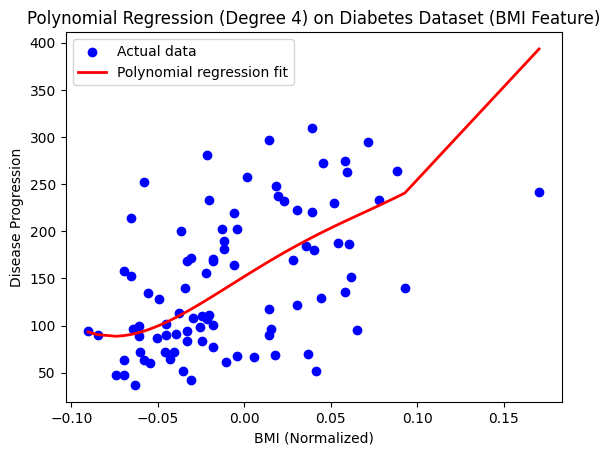

Mean Squared Error (MSE): 4085.85
Coefficient of Determination (R^2): 0.23


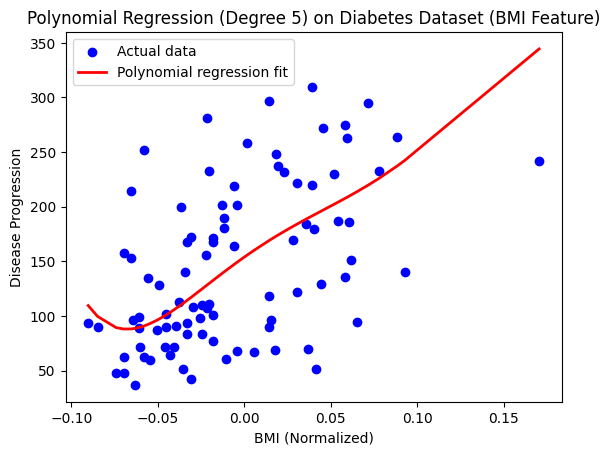

In [26]:

# Implement a Polynomial Regression model by extending the linear regression model with polynomial features.
# Train and test the model while comparing the results with those from the linear and multiple regression models.
from sklearn.preprocessing import PolynomialFeatures

#
for degree in [1, 2, 3, 4, 5]:
  poly = PolynomialFeatures(degree=degree, include_bias=False) # include_bias=False as LinearRegression handles the bias (intercept)

  # Fit and transform the training and test data
  X_train_poly = poly.fit_transform(X_train)
  X_test_poly = poly.transform(X_test)

  # 4. Train the polynomial regression model
  model = LinearRegression()
  model.fit(X_train_poly, y_train)

  # 5. Make predictions
  y_pred = model.predict(X_test_poly)

  # 6. Evaluate the model
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  print(f"Mean Squared Error (MSE): {mse:.2f}")
  print(f"Coefficient of Determination (R^2): {r2:.2f}")

  # 7. (Optional) Visualization (for a single feature)
  # Sort the test data for a smooth curve plot
  sort_idx = np.argsort(X_test.flatten())
  X_test_sorted = X_test[sort_idx]
  y_pred_sorted = y_pred[sort_idx]

  plt.scatter(X_test, y_test, color='blue', label='Actual data')
  plt.plot(X_test_sorted, y_pred_sorted, color='red', linewidth=2, label='Polynomial regression fit')
  plt.xlabel('BMI (Normalized)')
  plt.ylabel('Disease Progression')
  plt.title(f'Polynomial Regression (Degree {degree}) on Diabetes Dataset (BMI Feature)')
  plt.legend()
  plt.show()
